## Задание 1

Базово изучите датасет (достаточно методов info() и describe()).

Выдвиньте пару гипотез, например, “Верно ли, что чем выше ВВП, тем выше и уровень счастья?” или “Есть ли взаимосвязь между уровнем доверия правительству и уровнем счастья?”. Постарайтесь подтвердить или опровергнуть их визуально и с помощью расчётов.

Желательно, но не обязательно:
Составьте корреляционную матрицу всех числовых признаков набора данных и визуализируйте её с помощью тепловой карты.

## Описание датасета
Country - Name of the country.
happiness_score - Average of responses to the primary life evaluation question from the Gallup World Poll (GWP). 0-10 
Средний балл ответов на основной вопрос оценки жизни, полученный в ходе опроса Gallup World Poll (GWP). 0-10

gdp_per_capita - The extent to which GDP contributes to the calculation of the Happiness Score.
Степень, в которой ВВП влияет на расчет индекса счастья.

family - The extent to which Family contributes to the calculation of the Happiness Score

health - The extent to which Life expectancy contributed to the calculation of the Happiness Score
Степень, в которой ожидаемая продолжительность жизни повлияла на расчет индекса счастья

freedom - The extent to which Freedom contributed to the calculation of the Happiness Score

generosity - A numerical value calculated based on poll participants’ perceptions of generosity in their country.
Числовое значение, рассчитанное на основе восприятия участниками опроса щедрости в их стране.

government_trust - The extent to which Perception of Corruption contributes to Happiness Score.
Степень, в которой восприятие коррупции влияет на показатель счастья.

dystopia_residual - A score based on a hypothetical comparison to the world’s saddest country.
Оценка основана на гипотетическом сравнении с самой грустной страной мира.

continent - Region of the country.

In [1]:
import pandas as pd
import scipy.stats as st
from scipy.stats import ttest_ind
from scipy.stats import f_oneway, shapiro
import seaborn as sns

import matplotlib.pyplot as plt

In [3]:
data_happiness = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/hw6/Ноутбуки_к_ДЗ_Корреляция_и_регрессия/happines_corruption.csv')
data_happiness.head()

,Country,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,continent,Year,social_support,cpi_score
0,Norway,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,Europe,2015,0.0,88
1,Denmark,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,Europe,2015,0.0,91
2,Iceland,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,Europe,2015,0.0,79
3,Switzerland,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,Europe,2015,0.0,86
4,Finland,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,Europe,2015,0.0,90


In [4]:
data_happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 792 entries, 0 to 791
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            792 non-null    object 
 1   happiness_score    792 non-null    float64
 2   gdp_per_capita     792 non-null    float64
 3   family             792 non-null    float64
 4   health             792 non-null    float64
 5   freedom            792 non-null    float64
 6   generosity         792 non-null    float64
 7   government_trust   792 non-null    float64
 8   dystopia_residual  792 non-null    float64
 9   continent          792 non-null    object 
 10  Year               792 non-null    int64  
 11  social_support     792 non-null    float64
 12  cpi_score          792 non-null    int64  
dtypes: float64(9), int64(2), object(2)
memory usage: 80.6+ KB


In [12]:
data_happiness.describe() 

,happiness_score,gdp_per_capita,family,health,freedom,generosity,government_trust,dystopia_residual,Year,social_support,cpi_score
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000
mean,5.473310,0.929217,0.504998,0.648691,0.427016,0.212440,0.125720,1.379277,2017.500000,0.609302,44.327020
std,1.124726,0.385774,0.552736,0.232261,0.148003,0.121660,0.109032,1.075276,1.708904,0.640754,19.508833
min,2.566900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000,0.000000,11.000000
25%,4.590750,0.644242,0.000000,0.510070,0.325433,0.125784,0.052862,0.000000,2016.000000,0.000000,30.000000
50%,5.485500,0.994544,0.000000,0.685397,0.439621,0.197000,0.089000,1.731948,2017.500000,0.176214,38.000000
75%,6.300500,1.228677,1.040410,0.815641,0.546280,0.273250,0.154250,2.236894,2019.000000,1.268250,57.000000
max,7.808700,2.096000,1.610574,1.141000,0.724000,0.838075,0.551910,3.602140,2020.000000,1.644000,91.000000


Гипотезы: 
1) Верно ли, что чем выше уровень свободы в стране, тем больше уровень счастья?
2) Верно ли, что жители Европы счастливее жителей Африки?
3) Верно ли, что уровень здоровья определяет уровень счастья?


Проверка первой гипотезы

Проверка нормальности распределения данных

stat = 0.973, p = 0.0000000001
Вероятно не нормальное распределение


<Axes: ylabel='Density'>

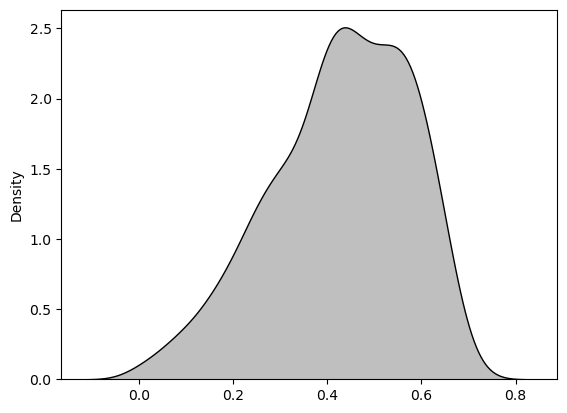

In [14]:

data_freedom = data_happiness['freedom'].values

stat, p = st.shapiro(data_freedom)
print(f'stat = {stat:.3f}, p = {p:.10f}')

if p > 0.05:
	print('Вероятно нормальное распределение')
else:
	print('Вероятно не нормальное распределение')
	
sns.kdeplot(data_freedom, label="Control", fill = True, color = '#000000')


stat = 0.985, p = 0.0000002562
Вероятно не нормальное распределение


<Axes: ylabel='Density'>

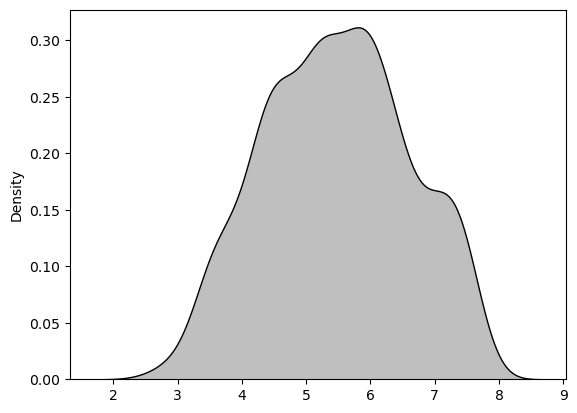

In [15]:
data_happiness_score = data_happiness['happiness_score'].values

stat, p = st.shapiro(data_happiness_score)
print(f'stat = {stat:.3f}, p = {p:.10f}')

if p > 0.05:
	print('Вероятно нормальное распределение')
else:
	print('Вероятно не нормальное распределение')
	
sns.kdeplot(data_happiness_score, label="Control", fill = True, color = '#000000')

Для выявления корреляции будем использовать коэффициент корреляции Спирмена

In [16]:
data_happiness[['happiness_score', 'freedom']].corr(method='spearman')

,happiness_score,freedom
happiness_score,1.000000,0.549513
freedom,0.549513,1.000000


Вывод: наличие свободы в странах слабо коррелирует с уровнем счастья

Text(0.5, 1.0, 'Зависимость уровня счастья от уровня свободы')

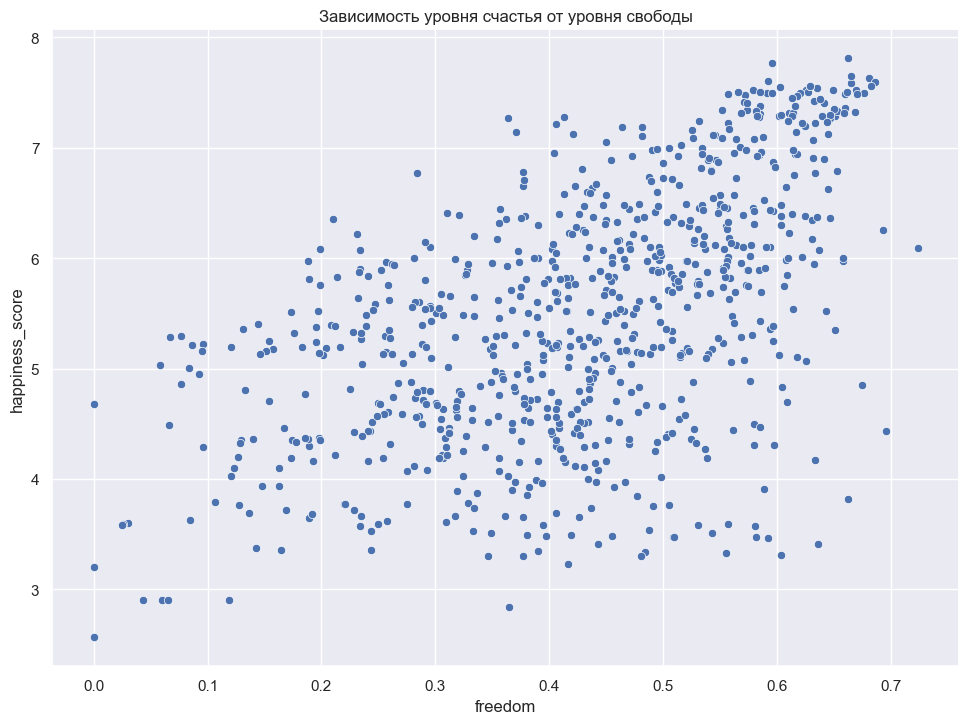

In [101]:

sns.scatterplot(data = data_happiness, x = 'freedom', y = 'happiness_score')
plt.title('Зависимость уровня счастья от уровня свободы')

Проверка второй гипотезы


Text(0.5, 1.0, 'Распределение уровня счастья по континентам')

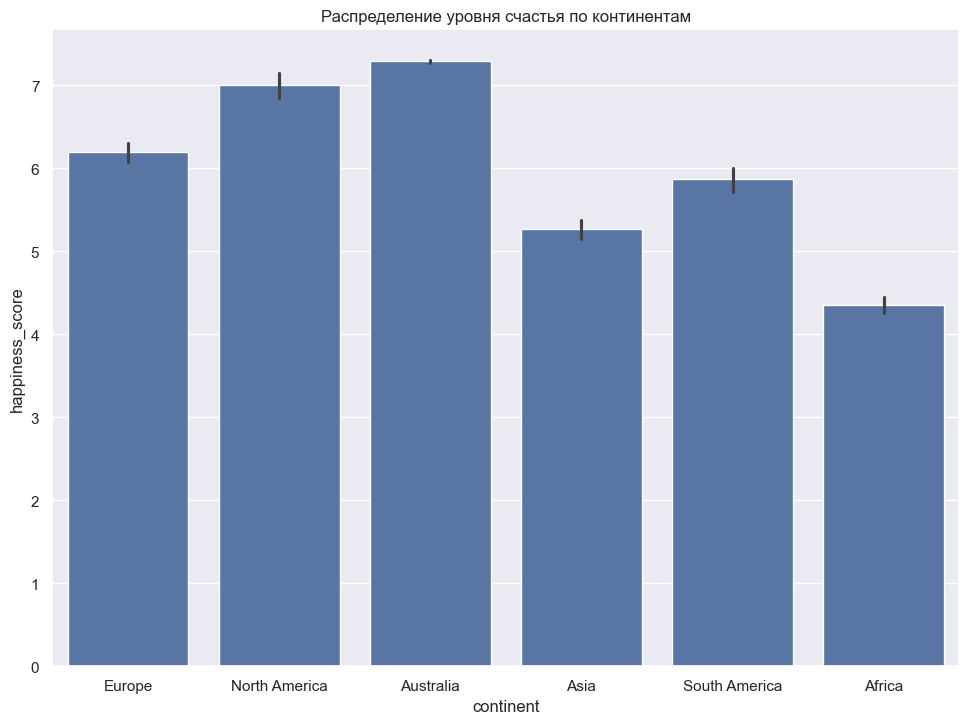

In [100]:
sns.barplot(data = data_happiness, x = 'continent', y = 'happiness_score')
plt.title('Распределение уровня счастья по континентам')


Столбчатая диаграмма демонстрирует подтверждение гипотезы, что жители Европы счастливее жителей Африки. Продемонстрируем это с помощью статистического теста

Нулевая гипотеза - различий между странами в уровне счастья нет

In [29]:
from scipy.stats import mannwhitneyu

europe_scores = data_happiness[data_happiness['continent'] == 'Europe']['happiness_score']
africa_scores = data_happiness[data_happiness['continent'] == 'Africa']['happiness_score']

stat, p = mannwhitneyu(europe_scores, africa_scores)
print(f'p-value:  {p:.55f}')

if p > 0.05:
	print('Вероятно, различий в уровне счастья нет')
else:
	print('Вероятно, различие в уровне счастья есть')

p-value:  0.0000000000000000000000000000000000000000000000000000001
Вероятно, различие в уровне счастья есть


In [30]:
data_happiness.groupby('continent')['happiness_score'].mean()

continent
Africa           4.353944
Asia             5.267553
Australia        7.289033
Europe           6.193717
North America    7.000539
South America    5.865516
Name: happiness_score, dtype: float64

Вывод: средний уровень счастья в Европе выше, чем в Африке

Проверка 3 гипотезы


Проверка нормальности распределения данных

stat = 0.968, p = 0.0000000000
Вероятно не нормальное распределение


<Axes: ylabel='Density'>

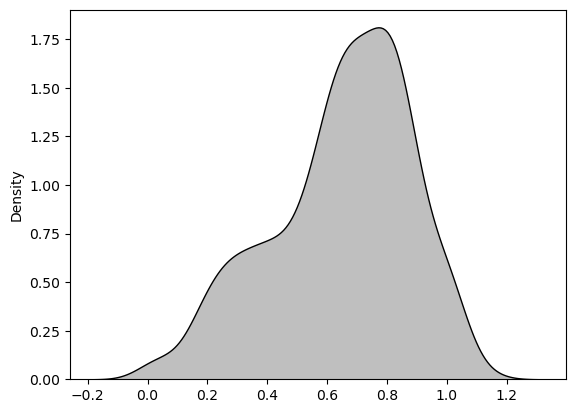

In [31]:
data_happiness_health = data_happiness['health'].values

stat, p = st.shapiro(data_happiness_health)
print(f'stat = {stat:.3f}, p = {p:.10f}')

if p > 0.05:
	print('Вероятно нормальное распределение')
else:
	print('Вероятно не нормальное распределение')
	
sns.kdeplot(data_happiness_health, label="Control", fill = True, color = '#000000')

Тогда для вычисления корреляции между данными будем использовать коэффициент Спирмена

In [34]:
data_happiness[['health','happiness_score']].corr(method='spearman')

,health,happiness_score
health,1.000000,0.765699
happiness_score,0.765699,1.000000


Вывод: уровень здоровья влияет на уровень счастья жителей

Text(0.5, 1.0, 'График зависимости уровня счастья от уровня здоровья')

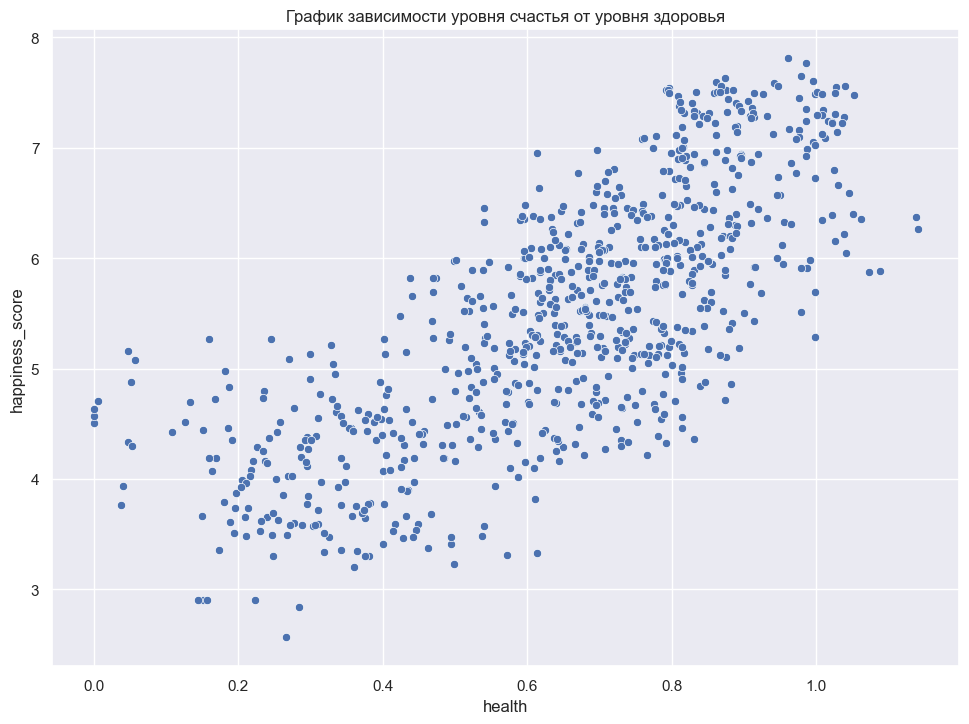

In [98]:
sns.scatterplot(data = data_happiness, x = 'health', y = 'happiness_score')
plt.title('График зависимости уровня счастья от уровня здоровья')

Данные выстраиваются приблизительно в прямую линию

Построение тепловой карты

<Axes: >

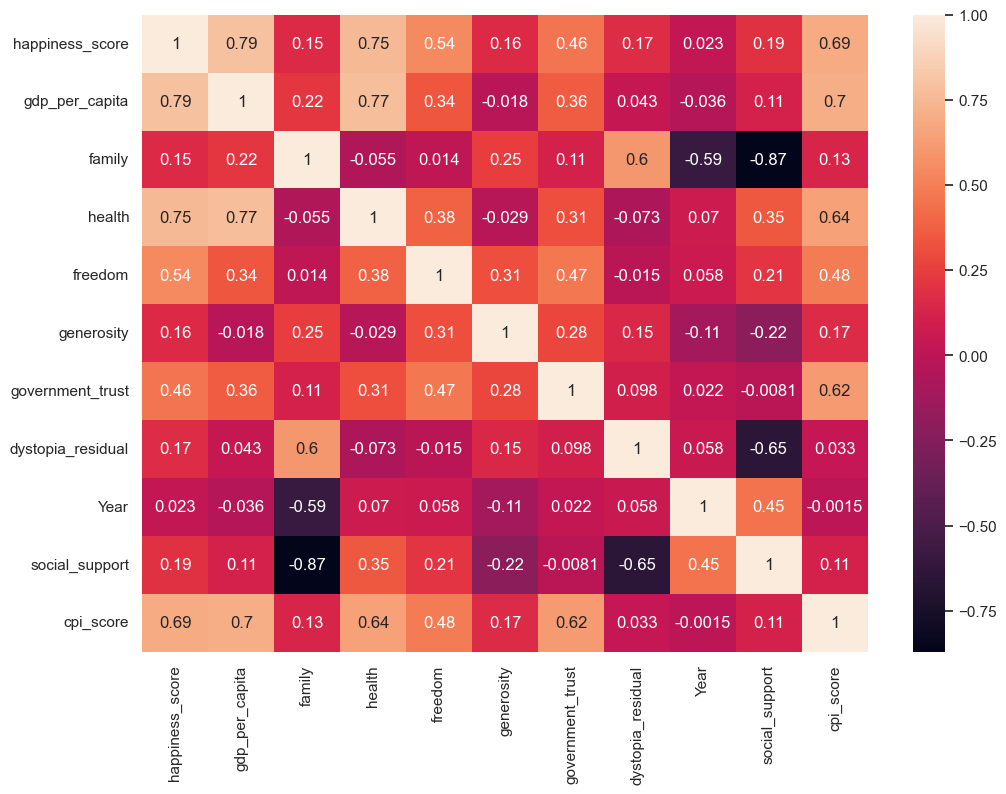

In [45]:
df = data_happiness.drop(['Country', 'continent'], axis=1)
sns.set(rc={'figure.figsize':(11.7,8.27)})
sns.heatmap(df.corr(), annot=True)

## Задание 2

Продолжаем изучать цены на газ в Южной Корее. Файл с данными “gas_sales_data.csv” вы сможете найти в материалах занятия (для этого набора данных вы ранее рассчитывали коэффициенты корреляции в тренажере).

В этом задании нужно окончательно ответить на вопрос:
Есть ли связь между среднемесячной температурой и потреблением газа в Южной Корее?

Для этого:

1) Оставьте только два столбца:'Temperature' и 'Sum'.
2) Постройте диаграмму рассеяния.
3) Постройте модель линейной регрессии для выбранных признаков.
4) Рассчитайте точность модели на тестовой выборке.
5) Выведите график остатков.

In [39]:
data_gas_sales = pd.read_csv('/Users/sofagusina/Desktop/программирование/machine_learning/статистика/statictics/hw6/Ноутбуки_к_ДЗ_Корреляция_и_регрессия/gas_sales_data.csv')[['Temperature','Sum']]
data_gas_sales.head()

,Temperature,Sum
0,-1.20,1717175
1,-0.99,1766341
2,6.64,1490537
3,12.11,1096964
4,17.59,790248


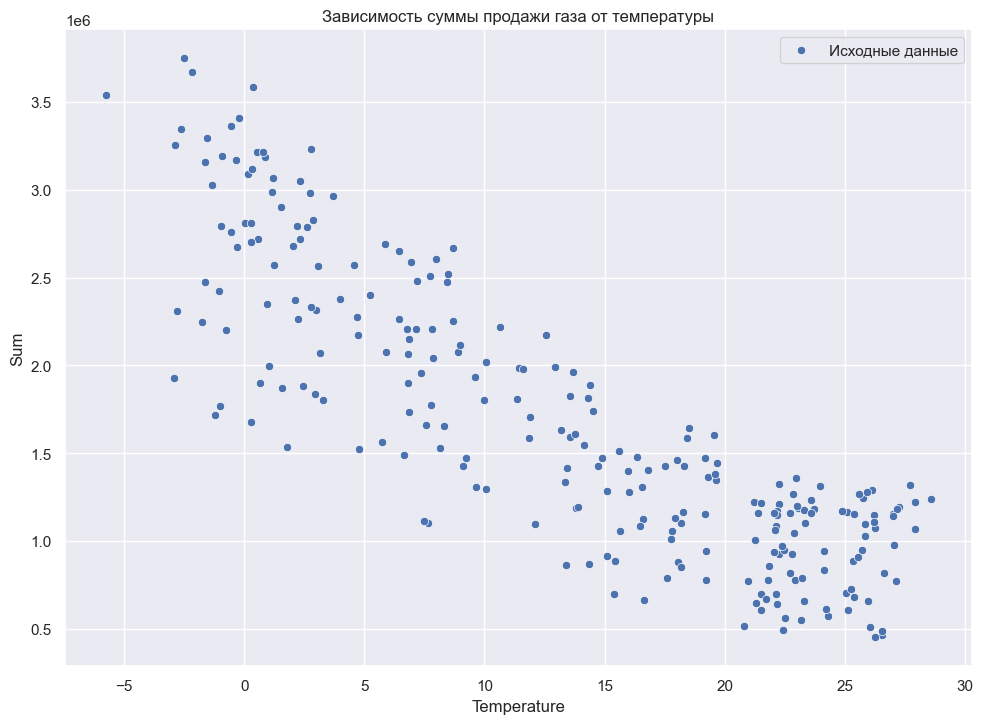

In [99]:
sns.scatterplot(data=data_gas_sales,x = 'Temperature',y='Sum', label='Исходные данные')
plt.title('Зависимость суммы продажи газа от температуры')
plt.legend()

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [58]:
X = data_gas_sales[['Temperature']]
Y = data_gas_sales['Sum']

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=42)

In [60]:
y_train.shape

(176,)

In [61]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [62]:
model.coef_

array([-69183.68395953])

In [63]:
model.intercept_

2571665.5705572804

y = 2571665 -69183x

In [65]:
y_pred = model.predict(X_test)
y_pred

array([1441204.17465859,  736914.27195059, 1659132.7791311 ,
       1246106.18589272,  805406.11907052, 1632842.97922648,
        641440.78808644,  691944.87737689, 1508312.34809933,
        832387.75581474, 2683051.30173212, 1971151.19378857,
       1969075.68326979, 1834167.49954871, 1041322.48137251,
       1211514.34391295, 1213589.85443174, 1615547.0582366 ,
       1100820.44957771, 2499714.53923937, 2099141.0091137 ,
        736222.43511099, 1431518.45890425, 1358875.59074675,
       1643912.36866   , 1983604.25690129,  816475.50850404,
       1625232.77399093, 2042410.38826689,  765279.58237399,
       1041322.48137251, 2609024.75989543,  956918.38694189,
       1934483.84129002, 1425291.92734789, 2344743.08717003,
       2294930.83471917,  769430.60341156, 2487953.31296625,
       2073543.04604868,  817167.34534364, 2968779.91648497,
       2721102.32790986, 2551602.30220902, 1580263.37941724,
       1906810.36770621, 1243338.83853433,  824777.55057919,
       1785738.92077704,

In [66]:
y_test

165    1480101
6       464203
111    1634442
172    1474082
115     907624
        ...   
119    2703917
75     1583588
113     949311
118    1776507
120    3256385
Name: Sum, Length: 76, dtype: int64

Точность модели на тестовой выборке

In [69]:
model.score(X_test, y_test)

0.769403571876491

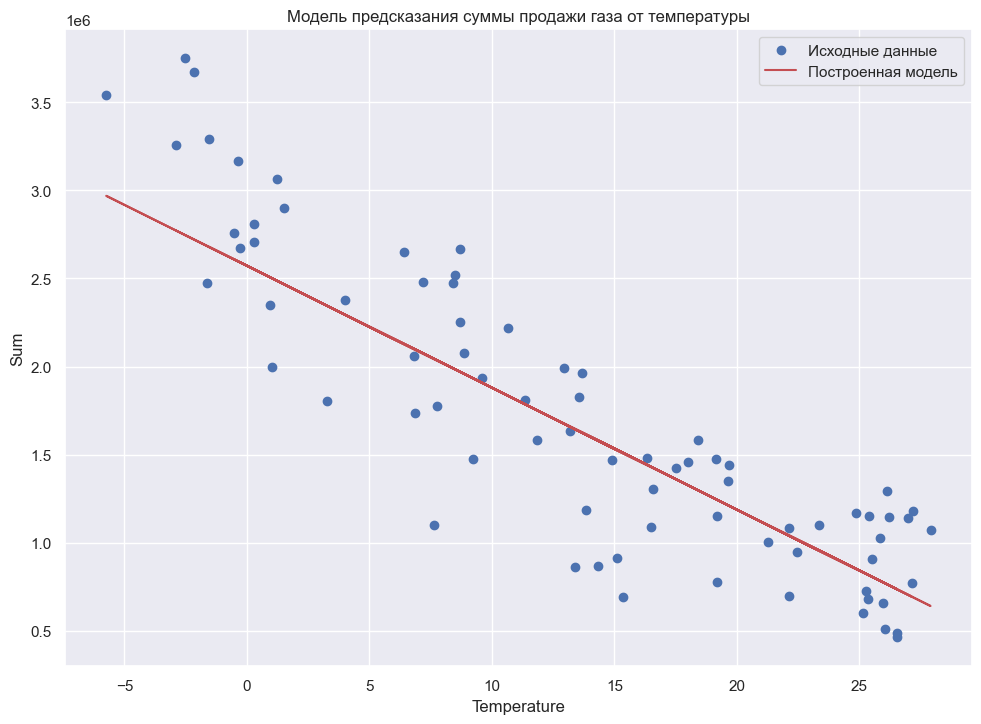

In [90]:
plt.scatter(X_test, y_test, label='Исходные данные')
plt.plot(X_test, y_pred, c='r', label='Построенная модель')
plt.xlabel('Temperature')
plt.ylabel('Sum')
plt.title('Модель предсказания суммы продажи газа от температуры')
plt.legend()
plt.grid(True)

Построение графика остатков

Если выбранная регрессионная модель хорошо описывает истинную зависимость, то остатки должны быть независимыми, нормально распределенными случайными величинами с нулевым средним, и в их значениях должен отсутствовать тренд.

 Анализ регрессионных остатков — это процесс проверки выполнения этих условий.

In [73]:
residuals = y_test - y_pred.flatten()
residuals


165     38896.825341
6     -272711.271951
111    -24690.779131
172    227975.814107
115    102217.880929
           ...      
119    152314.697791
75    -167559.078797
113    -69180.865666
118   -258293.183031
120    485470.419639
Name: Sum, Length: 76, dtype: float64

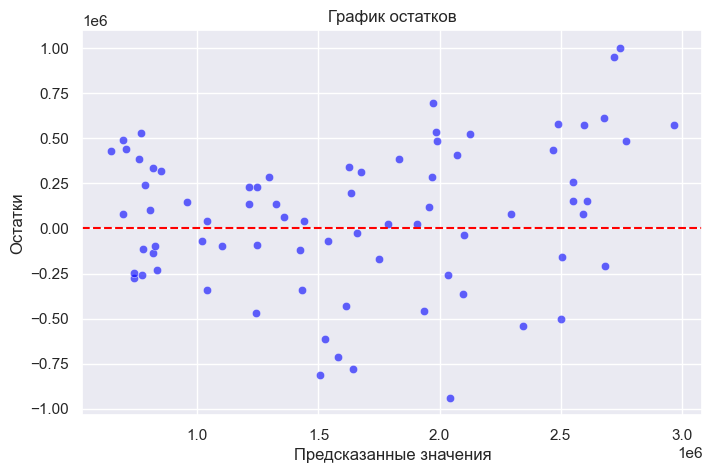

In [79]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x = y_pred, y = residuals, color='blue', alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True)
plt.show()

Вывод: модель хорошо описывает истинную зависимость, так как остатки не имеют четко выраженную закономерность